# Known information about the problem:
 The problem is to estimate the profit using Monte Carlo simulation.
 - Pofit = Sales * Price - Leads * cost_per_lead - Sales * cost_per_unit - Fixed_cost
 - Sales = Leads * Conversion_rate
 - Price = $50
 - Fixed_cost = $5000
 - Cost_per_lead = $0.65
 - Number of Leads: Discrete uniform between 1200 and 2000
 - Conversion rate: Continuous uniform between 0.1 and 0.3
 - Cost per unit: Normal with and average of $30 and a standard deviation of $5

 **What is the probability of this product being profitable?**

In [8]:
# Generate the random numbers
import scipy.stats as stats
import pandas as pd

replications = 1000

# Generate the random numbers for the leads. Generate random integers between 1200 and 2000 for the number of leads.
leads = stats.randint.rvs(1200, 2000, size=replications)
print(leads[:10])


# Generate the random numbers for the conversion rates. Generate random numbers between 0.1 and 0.3 for the conversion rates.
conversion_rates = stats.uniform.rvs(0.1, 0.2, size=replications)
print(conversion_rates[:10])


# Calculate the cost per unit. Generate random numbers from a normal distribution with a mean of 30 and a standard deviation of 5 for the cost per unit.
cost_per_unit = stats.norm.rvs(30, 5, size=replications)
print(cost_per_unit[:10])

[1341 1365 1732 1451 1307 1756 1921 1613 1739 1496]
[0.2294723  0.12684997 0.16618273 0.27507702 0.22271988 0.28552659
 0.17279046 0.1236683  0.1565943  0.14608864]
[25.97508203 25.10641881 26.65444209 42.03636433 23.90654443 32.71767259
 29.76038912 29.30779491 27.73032592 33.14057417]


Descriptive  statistics: 

             Profit
count   1000.000000
mean     411.644737
std     2664.228352
min    -4947.075127
25%    -1570.204219
50%      -10.668430
75%     2141.963508
max    12957.602540


Bins summary: 

Bin (-5000, -2500): 124
Bin (-2500, 0): 379
Bin (0, 2500): 273
Bin (2500, 5000): 159
Bin (5000, 7500): 56
Bin (7500, 10000): 6

Probability of loss = 0.503


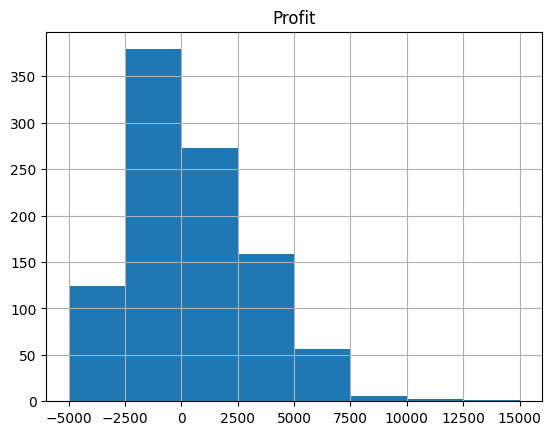

In [ ]:
import numpy
import pprint

# Define the parameters for the simulation
price = 50
fixed_cost = 5000
cost_per_lead = 0.65
profit = []


# Run the Monte Carlo simulation
for i in range(replications):
    # Calculate the number of sales
    sales = leads[i] * conversion_rates[i]
    # Calculate the total unit costs
    unit_costs = sales * cost_per_unit[i]
    # Calculate the leads costs
    leads_costs = leads[i] * cost_per_lead

    # Calculate profit and store it in the profit list
    profit.append((price * sales) - (fixed_cost + unit_costs + leads_costs))


# Print the results
profits_df = pd.DataFrame(profit, columns=['Profit'])

print("Descriptive  statistics: \n")
print(profits_df.describe())

#Create the table of the histogram
profits_histogramn = numpy.histogram(profit, bins=[-5000, -2500, 0, 2500, 5000, 7500, 10000, 12500, 15000])
print("\n\nBins summary: \n")
for i in range(6):
    print(f"Bin ({profits_histogramn[1][i]}, {profits_histogramn[1][i+1]}): {profits_histogramn[0][i]}")

# Create the histogram plot
profits_df.hist(bins=[-5000, -2500, 0, 2500, 5000, 7500, 10000, 12500, 15000])

# Calculate the probability of loss
print(f"\nProbability of loss = {(profits_df[profits_df['Profit'] < 0].shape[0] / profits_df.shape[0])}")
